<a href="https://colab.research.google.com/github/Subuktageen-Farooqi/ms_course_deeplearning/blob/main/ms_deeplearning_tutorial_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 15 — Long Short-Term Memory (LSTM)


## TensorFlow Implementation




[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker          GOOGL      GOOGL      GOOGL      GOOGL      GOOGL
Date                                                             
2010-01-04  15.555864  15.624368  15.493567  15.560828   78169752
2010-01-05  15.487362  15.582919  15.426554  15.566538  120067812
2010-01-06  15.096945  15.533775  15.049787  15.533775  158988852
2010-01-07  14.745496  15.140133  14.709508  15.125240  256315428
2010-01-08  14.942071  14.972598  14.621645  14.693375  188783028
X_train shape: (2942, 60, 1), y_train shape: (2942, 1)



c:\Users\HORIZON\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0048 - val_loss: 9.3576e-04
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.0252e-04 - val_loss: 0.0011
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.0676e-04 - val_loss: 9.2902e-04
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.1142e-04 - val_loss: 0.0012
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.0663e-04 - val_loss: 8.9362e-04
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 9.4048e-05 - val_loss: 0.0011
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 9.9580e-05 - val_loss: 7.5878e-04
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 8.7053e-05 - val_loss: 0.0011
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.0239e-04 - val_loss: 7.0091e-04
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 8.0700e-05 - val_loss: 6.7595e-04
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


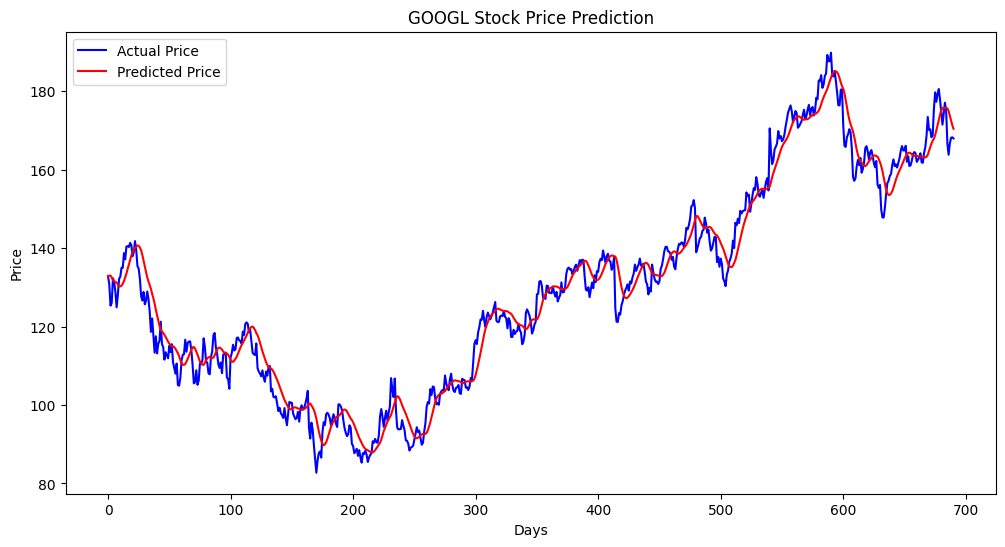

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted next day's price for GOOGL: $169.67


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Download GOOGL stock data
df = yf.download('GOOGL', start='2010-01-01', end='2024-12-01')
print(df.head())

# Focus on the 'Close' price for prediction
data = df['Close'].values.reshape(-1, 1)

# Scale data to the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Split into training (80%) and testing (20%) data
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

sequence_length = 60  # Use the past 60 days to predict the next day's price
X_train, y_train = create_sequences(train_data, sequence_length)
X_test, y_test = create_sequences(test_data, sequence_length)

# Reshape input for LSTM
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')

# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_test, y_test))

# Predict on the test data
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # Convert back to original scale

# Convert y_test to original scale
y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot predictions and actual prices
plt.figure(figsize=(12, 6))
plt.plot(y_test_scaled, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='red')
plt.title('GOOGL Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

# Use the last sequence from the scaled data
last_sequence = scaled_data[-sequence_length:].reshape(1, sequence_length, 1)

# Predict the next day's price
next_day_prediction = model.predict(last_sequence)
next_day_price = scaler.inverse_transform(next_day_prediction)
print(f"Predicted next day's price for GOOGL: ${next_day_price[0][0]:.2f}")


## PyTorch Implementation


[*********************100%***********************]  1 of 1 completed

Device: cuda
X_train: (2942, 60, 1) y_train: (2942, 1)
X_test: (751, 60, 1) y_test: (751, 1)


Epoch [1/10] Train MSE: 0.017461 | Test MSE: 0.006392
Epoch [2/10] Train MSE: 0.000261 | Test MSE: 0.003554
Epoch [3/10] Train MSE: 0.000196 | Test MSE: 0.003707
Epoch [4/10] Train MSE: 0.000199 | Test MSE: 0.003760
Epoch [5/10] Train MSE: 0.000190 | Test MSE: 0.003193
Epoch [6/10] Train MSE: 0.000201 | Test MSE: 0.003002
Epoch [7/10] Train MSE: 0.000238 | Test MSE: 0.002821
Epoch [8/10] Train MSE: 0.000217 | Test MSE: 0.002216
Epoch [9/10] Train MSE: 0.000166 | Test MSE: 0.002118
Epoch [10/10] Train MSE: 0.000163 | Test MSE: 0.002007
PyTorch LSTM Test RMSE: 6.0988
PyTorch LSTM Test MAE: 4.8242


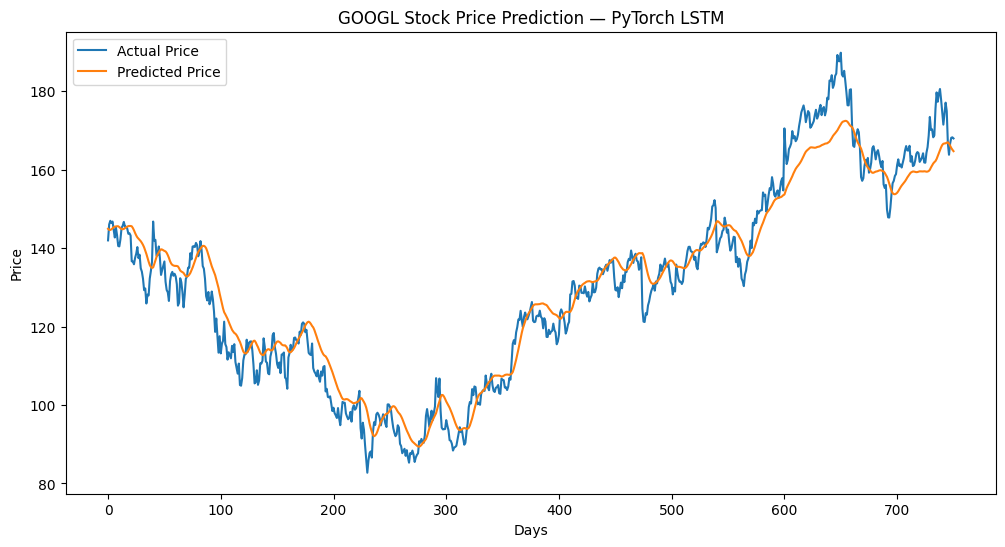

Predicted next day's price for GOOGL: $164.40


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

df_pt = yf.download("GOOGL", start="2010-01-01", end="2024-12-01")
close_prices = df_pt["Close"].values.reshape(-1, 1).astype(np.float32)

sequence_length = 60
train_size = int(len(close_prices) * 0.8)

train_raw = close_prices[:train_size]
test_raw = close_prices[train_size - sequence_length:]  # keep lookback context

scaler_pt = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler_pt.fit_transform(train_raw)
test_scaled = scaler_pt.transform(test_raw)

def create_sequences_np(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train_pt, y_train_pt = create_sequences_np(train_scaled, sequence_length)
X_test_pt, y_test_pt = create_sequences_np(test_scaled, sequence_length)

print("X_train:", X_train_pt.shape, "y_train:", y_train_pt.shape)
print("X_test:", X_test_pt.shape, "y_test:", y_test_pt.shape)

class StockSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader_pt = DataLoader(
    StockSequenceDataset(X_train_pt, y_train_pt),
    batch_size=32,
    shuffle=True
)

test_loader_pt = DataLoader(
    StockSequenceDataset(X_test_pt, y_test_pt),
    batch_size=32,
    shuffle=False
)

class StockLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 25),
            nn.ReLU(),
            nn.Linear(25, 1)
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        last_output = output[:, -1, :]
        return self.regressor(last_output)

def train_stock_model(model, train_loader, test_loader, epochs=10, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"epoch": [], "train_loss": [], "test_loss": []}

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        model.eval()
        total_test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                total_test_loss += loss.item()

        avg_test_loss = total_test_loss / len(test_loader)
        history["epoch"].append(epoch + 1)
        history["train_loss"].append(avg_train_loss)
        history["test_loss"].append(avg_test_loss)

        print(f"Epoch [{epoch+1}/{epochs}] Train MSE: {avg_train_loss:.6f} | Test MSE: {avg_test_loss:.6f}")

    return pd.DataFrame(history)

stock_lstm = StockLSTM(input_size=1, hidden_size=50, num_layers=2).to(device)
stock_history = train_stock_model(stock_lstm, train_loader_pt, test_loader_pt, epochs=10, lr=0.001)

def predict_stock_model(model, X, scaler):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.from_numpy(X).to(device)
        preds_scaled = model(X_tensor).cpu().numpy()
    return scaler.inverse_transform(preds_scaled)

test_predictions = predict_stock_model(stock_lstm, X_test_pt, scaler_pt)
y_test_original = scaler_pt.inverse_transform(y_test_pt.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_original, test_predictions))
mae = mean_absolute_error(y_test_original, test_predictions)

print(f"PyTorch LSTM Test RMSE: {rmse:.4f}")
print(f"PyTorch LSTM Test MAE: {mae:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label="Actual Price")
plt.plot(test_predictions, label="Predicted Price")
plt.title("GOOGL Stock Price Prediction — PyTorch LSTM")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

last_sequence_pt = scaler_pt.transform(close_prices[-sequence_length:]).reshape(1, sequence_length, 1).astype(np.float32)
with torch.no_grad():
    next_day_scaled = stock_lstm(torch.from_numpy(last_sequence_pt).to(device)).cpu().numpy()

next_day_price_pt = scaler_pt.inverse_transform(next_day_scaled)
print(f"Predicted next day's price for GOOGL: ${next_day_price_pt[0][0]:.2f}")


## Task 1 — Compare LSTM with Simple RNN


Epoch [1/10] Train MSE: 0.017150 | Test MSE: 0.007976
Epoch [2/10] Train MSE: 0.000190 | Test MSE: 0.003252
Epoch [3/10] Train MSE: 0.000105 | Test MSE: 0.002128
Epoch [4/10] Train MSE: 0.000094 | Test MSE: 0.001734
Epoch [5/10] Train MSE: 0.000110 | Test MSE: 0.002206
Epoch [6/10] Train MSE: 0.000144 | Test MSE: 0.001667
Epoch [7/10] Train MSE: 0.000119 | Test MSE: 0.002172
Epoch [8/10] Train MSE: 0.000100 | Test MSE: 0.001402
Epoch [9/10] Train MSE: 0.000106 | Test MSE: 0.001422
Epoch [10/10] Train MSE: 0.000100 | Test MSE: 0.001196


,Model,RMSE,MAE
0,LSTM,6.098768,4.824151
1,Simple RNN,4.672469,3.583108


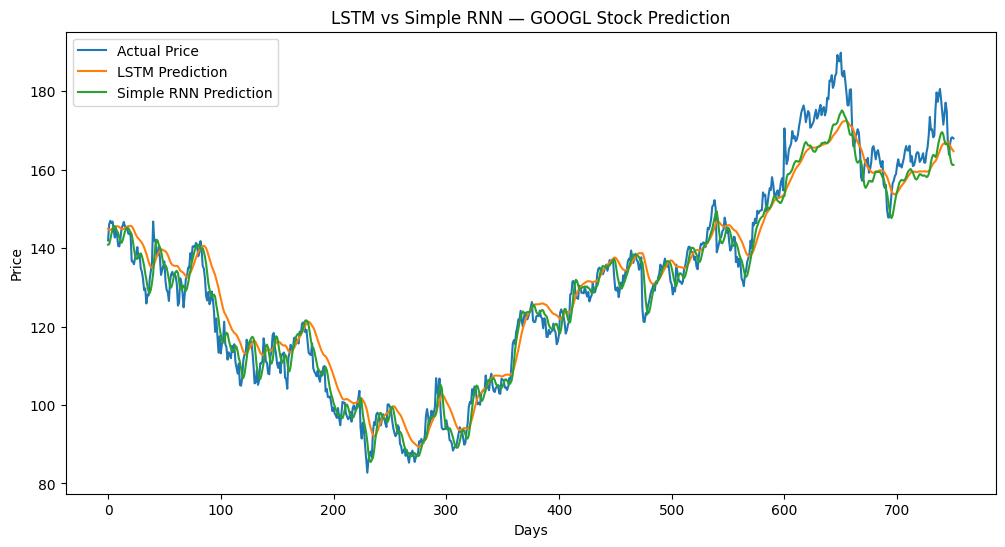

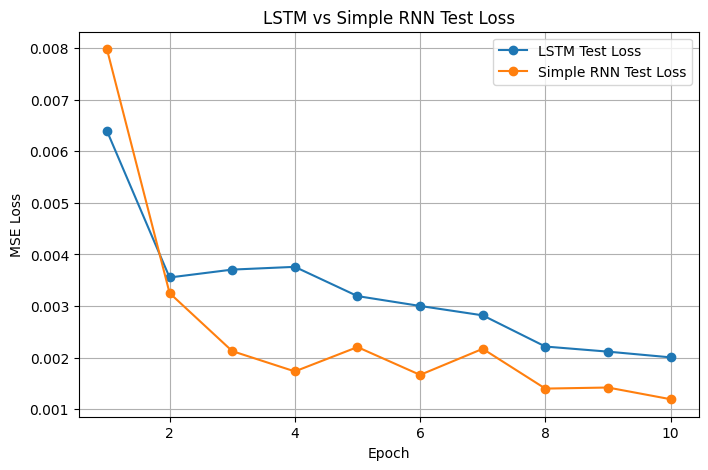

In [ ]:
class StockSimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity="tanh",
            batch_first=True
        )
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 25),
            nn.ReLU(),
            nn.Linear(25, 1)
        )

    def forward(self, x):
        output, _ = self.rnn(x)
        last_output = output[:, -1, :]
        return self.regressor(last_output)

simple_rnn = StockSimpleRNN(input_size=1, hidden_size=50, num_layers=2).to(device)
rnn_history = train_stock_model(simple_rnn, train_loader_pt, test_loader_pt, epochs=10, lr=0.001)

rnn_predictions = predict_stock_model(simple_rnn, X_test_pt, scaler_pt)

rnn_rmse = np.sqrt(mean_squared_error(y_test_original, rnn_predictions))
rnn_mae = mean_absolute_error(y_test_original, rnn_predictions)

comparison_df = pd.DataFrame([
    {"Model": "LSTM", "RMSE": rmse, "MAE": mae},
    {"Model": "Simple RNN", "RMSE": rnn_rmse, "MAE": rnn_mae},
])
display(comparison_df)

plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label="Actual Price")
plt.plot(test_predictions, label="LSTM Prediction")
plt.plot(rnn_predictions, label="Simple RNN Prediction")
plt.title("LSTM vs Simple RNN — GOOGL Stock Prediction")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(stock_history["epoch"], stock_history["test_loss"], marker="o", label="LSTM Test Loss")
plt.plot(rnn_history["epoch"], rnn_history["test_loss"], marker="o", label="Simple RNN Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM vs Simple RNN Test Loss")
plt.legend()
plt.grid(True)
plt.show()


## Task 2 — LSTM for Sentiment Analysis

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Epoch [1/5] Train Loss: 0.6933 | Test Loss: 0.6932 | Test Acc: 0.4978
Epoch [2/5] Train Loss: 0.6882 | Test Loss: 0.6959 | Test Acc: 0.5132
Epoch [3/5] Train Loss: 0.6781 | Test Loss: 0.6948 | Test Acc: 0.5260
Epoch [4/5] Train Loss: 0.6503 | Test Loss: 0.6573 | Test Acc: 0.6314
Epoch [5/5] Train Loss: 0.6400 | Test Loss: 0.7035 | Test Acc: 0.5384


,epoch,train_loss,test_loss,test_acc
0,1,0.693276,0.693247,0.4978
1,2,0.688172,0.695919,0.5132
2,3,0.678105,0.694757,0.5260
3,4,0.650332,0.657347,0.6314
4,5,0.639960,0.703503,0.5384


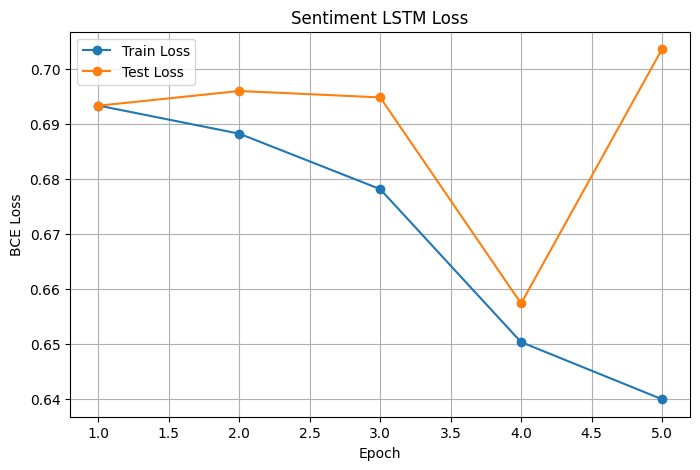

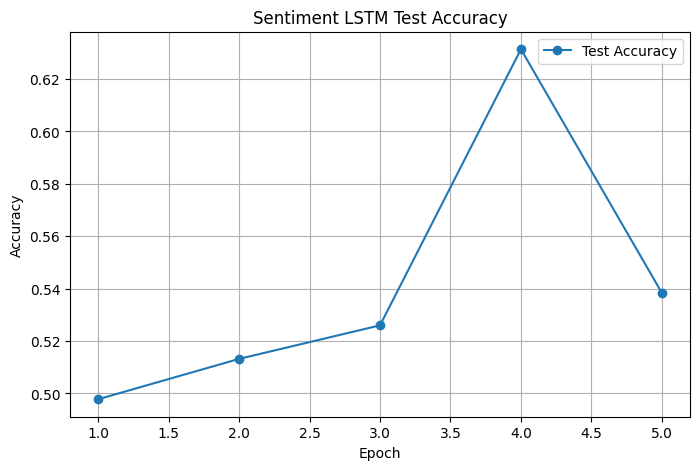

In [ ]:
try:
    from tensorflow.keras.datasets import imdb
    from tensorflow.keras.preprocessing.sequence import pad_sequences
except Exception as e:
    raise ImportError("This cell needs TensorFlow/Keras only to load the pre-tokenized IMDb dataset.") from e

VOCAB_SIZE = 10000
MAX_LEN = 200
SENTIMENT_EPOCHS = 5
SENTIMENT_BATCH_SIZE = 128

(x_train_sent, y_train_sent), (x_test_sent, y_test_sent) = imdb.load_data(num_words=VOCAB_SIZE)

MAX_SENTIMENT_TRAIN = 12000
MAX_SENTIMENT_TEST = 5000

x_train_sent = x_train_sent[:MAX_SENTIMENT_TRAIN]
y_train_sent = y_train_sent[:MAX_SENTIMENT_TRAIN]
x_test_sent = x_test_sent[:MAX_SENTIMENT_TEST]
y_test_sent = y_test_sent[:MAX_SENTIMENT_TEST]

x_train_pad = pad_sequences(x_train_sent, maxlen=MAX_LEN, padding="post", truncating="post")
x_test_pad = pad_sequences(x_test_sent, maxlen=MAX_LEN, padding="post", truncating="post")

class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

sent_train_loader = DataLoader(
    SentimentDataset(x_train_pad, y_train_sent),
    batch_size=SENTIMENT_BATCH_SIZE,
    shuffle=True
)

sent_test_loader = DataLoader(
    SentimentDataset(x_test_pad, y_test_sent),
    batch_size=SENTIMENT_BATCH_SIZE,
    shuffle=False
)

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size=10000, embed_dim=64, hidden_size=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.lstm(embedded)
        last_output = output[:, -1, :]
        return self.classifier(last_output)

sentiment_model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,
    hidden_size=64
).to(device)

sentiment_criterion = nn.BCELoss()
sentiment_optimizer = torch.optim.Adam(sentiment_model.parameters(), lr=0.001)

def evaluate_sentiment(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            probs = model(X_batch)
            loss = sentiment_criterion(probs, y_batch)

            preds = (probs >= 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += y_batch.numel()
            total_loss += loss.item()

    return total_loss / len(loader), correct / total

sentiment_history = {"epoch": [], "train_loss": [], "test_loss": [], "test_acc": []}

for epoch in range(SENTIMENT_EPOCHS):
    sentiment_model.train()
    total_train_loss = 0.0

    for X_batch, y_batch in sent_train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        sentiment_optimizer.zero_grad()
        probs = sentiment_model(X_batch)
        loss = sentiment_criterion(probs, y_batch)

        loss.backward()
        sentiment_optimizer.step()
        total_train_loss += loss.item()

    train_loss = total_train_loss / len(sent_train_loader)
    test_loss, test_acc = evaluate_sentiment(sentiment_model, sent_test_loader)

    sentiment_history["epoch"].append(epoch + 1)
    sentiment_history["train_loss"].append(train_loss)
    sentiment_history["test_loss"].append(test_loss)
    sentiment_history["test_acc"].append(test_acc)

    print(f"Epoch [{epoch+1}/{SENTIMENT_EPOCHS}] Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

sentiment_history_df = pd.DataFrame(sentiment_history)
display(sentiment_history_df)

plt.figure(figsize=(8, 5))
plt.plot(sentiment_history_df["epoch"], sentiment_history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(sentiment_history_df["epoch"], sentiment_history_df["test_loss"], marker="o", label="Test Loss")
plt.title("Sentiment LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(sentiment_history_df["epoch"], sentiment_history_df["test_acc"], marker="o", label="Test Accuracy")
plt.title("Sentiment LSTM Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
